## 1. Persiapan library dan konfigurasi

In [1]:
# BLOK 1 — Memuat library dan menetapkan parameter agar eksperimen dapat direproduksi.
# Jika diperlukan di Google Colab:
# !pip -q install openpyxl

import re
import time
import warnings
from itertools import permutations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Konfigurasi utama yang boleh diubah
K_MIN, K_MAX = 2, 3
K_FINAL = 3  # penyederhanaan menjadi tiga topik utama
MAX_FEATURES = 1500
MIN_DF = 2
MAX_DF = 0.95
N_LSA_COMPONENTS = 25
N_PARTICLES = 30
N_ITERATIONS = 40
EXPERIMENT_SEEDS = list(range(10))
INERTIA_WEIGHT = 0.72
COGNITIVE_WEIGHT = 1.49
SOCIAL_WEIGHT = 1.49

print('Konfigurasi siap.')

Konfigurasi siap.


## 2. Memuat dua dataset

In [2]:
# BLOK 2 — Mencari dan memuat data ulasan bersih serta data mentah dari lokasi yang tersedia.
def temukan_file(nama_file):
    kandidat = [
        Path(nama_file),
        Path('upload') / nama_file,
        Path('/content') / nama_file,
    ]
    for path in kandidat:
        if path.exists():
            return path
    raise FileNotFoundError(
        f'{nama_file} tidak ditemukan. Letakkan file di folder yang sama dengan notebook '
        'atau unggah ke /content jika menggunakan Google Colab.'
    )

clean_path = temukan_file('dataset_review_clean_final.xlsx')
raw_path = temukan_file('seluruh_review_Bapenda_Sulsel_Mobile.xlsx')

df_clean = pd.read_excel(clean_path, sheet_name='Sheet1')
df_raw = pd.read_excel(raw_path, sheet_name='Review')

assert 'review_clean_final' in df_clean.columns, 'Kolom review_clean_final tidak ditemukan.'
assert 'content' in df_raw.columns, 'Kolom content tidak ditemukan pada data mentah.'

print(f'Data bersih : {df_clean.shape[0]:,} baris × {df_clean.shape[1]} kolom')
print(f'Data mentah : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
display(df_clean.head())
display(df_raw[['content', 'score', 'at', 'appVersion']].head())

Data bersih : 377 baris × 1 kolom
Data mentah : 671 baris × 11 kolom


,review_clean_final
0,mantap aplikasi nya sangat membantu
1,memudahkan bagi masyarakat pengguna pajak kendaraan bermotor
2,apakah tidak bisa dipermudah apabila pkb ketinggalan bisa menunjukkan pkb yg online aplikasi harusnya sih pemerintah...
3,di benahi sistem dan proses pengurusan pajak kendaraan di samsat bulukumba menunggu berjam datang baru langsung pros...
4,terhitung akhir bulan mei aplikasi ini selalu error tidak bisa melakukan pengecekan padahal sudah update yang terbaru


,content,score,at,appVersion
0,mantap aplikasi nya sangat membantu,5,2026-06-22 09:00:14,3.2.0
1,nice aplikasi,5,2026-06-19 23:31:54,3.2.1
2,aplikasi bagus banget,5,2026-06-15 12:36:01,3.2.1
3,memudahkan bagi masyarakat pengguna pajak kendaraan bermotor,4,2026-06-14 17:35:58,3.2.1
4,bermanfaat,5,2026-06-13 07:53:38,3.1.0


## 3. Validasi dan ringkasan data

,indikator,nilai
0,Jumlah ulasan bersih awal,377.000
1,Jumlah ulasan setelah validasi,377.000
2,Duplikat/kosong terhapus,0.000
3,Jumlah ulasan mentah,671.000
4,Rata-rata skor data mentah,3.897


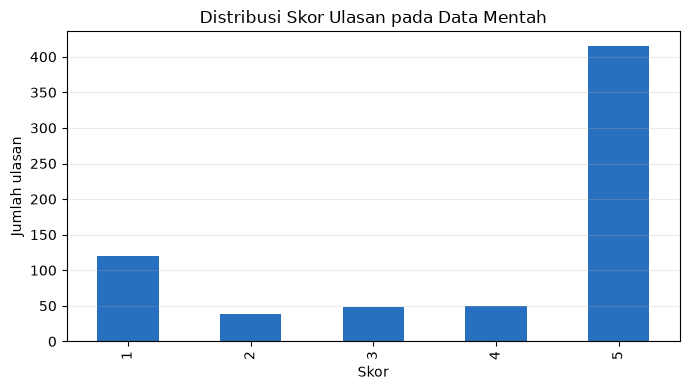

In [3]:
# BLOK 3 — Memeriksa kelayakan data, menghapus data tidak valid, lalu menampilkan ringkasannya.
# Validasi memastikan hanya ulasan teks yang layak dipakai model.
n_awal = len(df_clean)
data = df_clean[['review_clean_final']].copy()
data['review_clean_final'] = data['review_clean_final'].astype(str).str.strip()
data = data[data['review_clean_final'].str.len() > 0]
data = data.drop_duplicates(subset='review_clean_final').reset_index(drop=True)

ringkasan = pd.DataFrame({
    'indikator': [
        'Jumlah ulasan bersih awal',
        'Jumlah ulasan setelah validasi',
        'Duplikat/kosong terhapus',
        'Jumlah ulasan mentah',
        'Rata-rata skor data mentah',
    ],
    'nilai': [n_awal, len(data), n_awal - len(data), len(df_raw), round(df_raw['score'].mean(), 3)]
})
display(ringkasan)

score_counts = df_raw['score'].value_counts().sort_index()
ax = score_counts.plot(kind='bar', color='#276FBF', figsize=(7, 4))
ax.set_title('Distribusi Skor Ulasan pada Data Mentah')
ax.set_xlabel('Skor')
ax.set_ylabel('Jumlah ulasan')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Normalisasi, TF-IDF, dan Latent Semantic Analysis (LSA)

In [4]:
# BLOK 4 — Menyiapkan teks menjadi vektor numerik TF-IDF dan mereduksi dimensinya dengan LSA.
STOPWORDS_ID = {
    'ada','adalah','agar','akan','aku','anda','atau','bagi','bahwa','bisa','buat','dalam','dan',
    'dari','dengan','di','dia','ini','itu','jadi','juga','karena','ke','kok','lagi','lebih','maka',
    'masih','mau','mohon','nya','oleh','pada','para','pun','saja','sangat','saya','sebagai','seperti',
    'sudah','supaya','tak','tidak','untuk','yang','ya','yg','aplikasi','app','bapenda','sulsel'
}
NORMALISASI_KATA = {
    'tdk':'tidak', 'gk':'tidak', 'ga':'tidak', 'gak':'tidak', 'nggak':'tidak',
    'sy':'saya', 'sya':'saya', 'knpa':'kenapa', 'klo':'kalau', 'kalo':'kalau',
    'sdh':'sudah', 'blm':'belum', 'dgn':'dengan', 'utk':'untuk', 'krn':'karena',
    'tp':'tetapi', 'tpi':'tetapi', 'jd':'jadi', 'org':'orang', 'apk':'aplikasi',
    'aplikasinya':'aplikasi', 'daplikasi':'di aplikasi', 'disamsat':'di samsat',
    'pajakada':'pajak ada', 'carax':'caranya', 'biayany':'biayanya'
}

# Normalisasi menyatukan variasi penulisan agar kata dengan makna sama dihitung sebagai fitur yang sama.
def normalisasi_teks(teks):
    teks = str(teks).lower()
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    token_baru = []
    for token in teks.split():
        token_baru.extend(NORMALISASI_KATA.get(token, token).split())
    return re.sub(r'\s+', ' ', ' '.join(token_baru)).strip()

# Kolom asli dipertahankan; kolom baru ini khusus digunakan sebagai masukan model.
data['teks_model'] = data['review_clean_final'].map(normalisasi_teks)
data = data[data['teks_model'].str.len() > 0].reset_index(drop=True)

# TF-IDF memberi bobot tinggi pada kata/frasa yang khas; unigram dan bigram menangkap konteks pendek.
vectorizer = TfidfVectorizer(
    stop_words=list(STOPWORDS_ID), ngram_range=(1, 2), min_df=MIN_DF, max_df=MAX_DF,
    max_features=MAX_FEATURES, sublinear_tf=True
)
# Normalisasi L2 menyetarakan panjang vektor sehingga ulasan panjang tidak otomatis lebih dominan.
X_tfidf = normalize(vectorizer.fit_transform(data['teks_model']), norm='l2', copy=False)
feature_names = np.asarray(vectorizer.get_feature_names_out())

# Jumlah komponen dibatasi ukuran data agar TruncatedSVD selalu menerima dimensi yang valid.
n_components = min(N_LSA_COMPONENTS, X_tfidf.shape[1] - 1, X_tfidf.shape[0] - 1)
lsa = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X = normalize(lsa.fit_transform(X_tfidf), norm='l2')

print('Matriks TF-IDF:', X_tfidf.shape)
print('Sparsity TF-IDF: {:.2%}'.format(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])))
print('Matriks LSA untuk klastering:', X.shape)
print('Variansi kumulatif LSA: {:.2%}'.format(lsa.explained_variance_ratio_.sum()))
assert X.shape[0] >= K_MAX, 'Jumlah dokumen terlalu sedikit.'
assert X.shape[1] > 1, 'Dimensi LSA tidak mencukupi.'

Matriks TF-IDF: (377, 739)
Sparsity TF-IDF: 98.61%
Matriks LSA untuk klastering: (377, 25)
Variansi kumulatif LSA: 24.78%


## 5. Menentukan jumlah klaster kandidat

,k,silhouette,davies_bouldin,calinski_harabasz,inertia_sse,waktu_detik
0,2,0.1059,3.7984,25.0213,310.7241,0.1870
1,3,0.1265,3.5482,23.1387,294.9595,0.2022


K dengan Silhouette tertinggi pada rentang uji: 3
K final untuk model dan pelabelan: 3


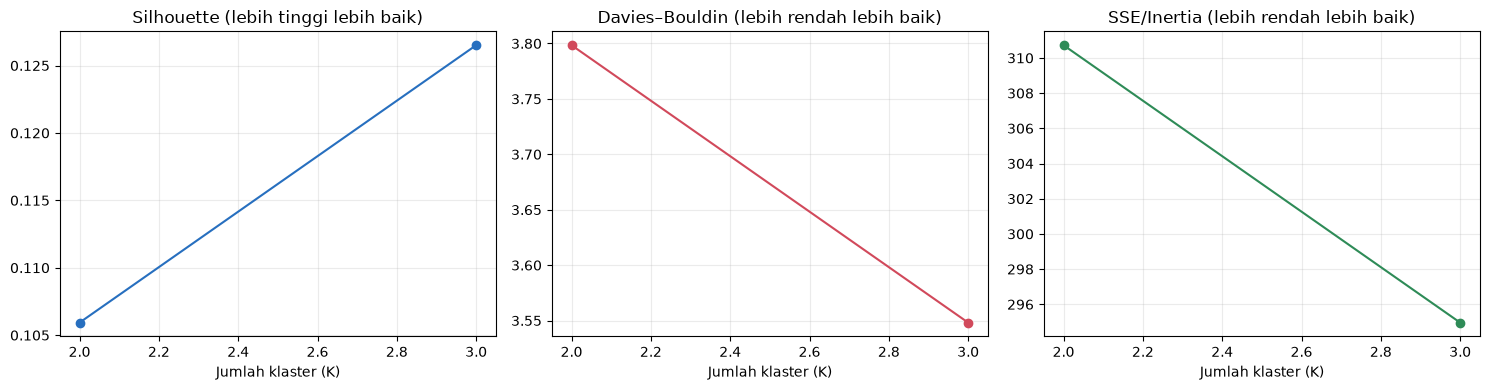

In [5]:
# BLOK 5 — Menguji beberapa nilai K untuk menilai jumlah klaster yang paling sesuai.
# Mengumpulkan metrik internal untuk membandingkan kualitas klaster tanpa label topik acuan.
def hitung_metrik(X_eval, labels, inertia, waktu):
    # Metrik eksternal tidak tersedia karena dataset tidak memiliki label topik acuan.
    n_clusters_found = len(np.unique(labels))
    if n_clusters_found < 2:
        return {'silhouette': np.nan, 'davies_bouldin': np.nan, 'calinski_harabasz': np.nan,
                'inertia_sse': inertia, 'waktu_detik': waktu}
    return {
        'silhouette': silhouette_score(X_eval, labels, metric='cosine'),
        'davies_bouldin': davies_bouldin_score(X_eval, labels),
        'calinski_harabasz': calinski_harabasz_score(X_eval, labels),
        'inertia_sse': inertia,
        'waktu_detik': waktu,
    }

hasil_k = []
model_kandidat = {}
# Setiap kandidat K dilatih dengan konfigurasi yang sama agar perbandingannya adil.
for k in range(K_MIN, K_MAX + 1):
    mulai = time.perf_counter()
    model = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=300, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    durasi = time.perf_counter() - mulai
    metrik = hitung_metrik(X, labels, model.inertia_, durasi)
    hasil_k.append({'k': k, **metrik})
    model_kandidat[k] = model

df_k = pd.DataFrame(hasil_k)
# Silhouette tertinggi menjadi referensi empiris; K final tetap mengikuti kebutuhan tiga topik penelitian.
K_SILHOUETTE = int(df_k.loc[df_k['silhouette'].idxmax(), 'k'])
K_TERBAIK = K_FINAL
display(df_k.round(4))
print(f'K dengan Silhouette tertinggi pada rentang uji: {K_SILHOUETTE}')
print(f'K final untuk model dan pelabelan: {K_TERBAIK}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_k['k'], df_k['silhouette'], marker='o', color='#276FBF')
axes[0].set_title('Silhouette (lebih tinggi lebih baik)')
axes[1].plot(df_k['k'], df_k['davies_bouldin'], marker='o', color='#D1495B')
axes[1].set_title('Davies–Bouldin (lebih rendah lebih baik)')
axes[2].plot(df_k['k'], df_k['inertia_sse'], marker='o', color='#2E8B57')
axes[2].set_title('SSE/Inertia (lebih rendah lebih baik)')
for ax in axes:
    ax.set_xlabel('Jumlah klaster (K)')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. K-Means standar sebagai baseline

In [6]:
# BLOK 6 — Menetapkan K-Means acak sebagai baseline pembanding sebelum optimasi PSO.
print(f'Evaluasi akan dijalankan pada {len(EXPERIMENT_SEEDS)} seed: {EXPERIMENT_SEEDS}')
print('Baseline: K-Means random satu inisialisasi per seed.')

Evaluasi akan dijalankan pada 10 seed: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Baseline: K-Means random satu inisialisasi per seed.


## 7. Implementasi Particle Swarm Optimization

In [7]:
# BLOK 7 — Mendefinisikan fungsi PSO dan penyempurnaan K-Means untuk mengoptimalkan centroid.
# Menghitung jarak Euclidean kuadrat seluruh data ke seluruh centroid secara tervektorisasi.
def jarak_kuadrat(X_dense, centers):
    x_norm = np.sum(X_dense * X_dense, axis=1)[:, None]
    c_norm = np.sum(centers * centers, axis=1)[None, :]
    return np.maximum(x_norm + c_norm - 2.0 * X_dense @ centers.T, 0.0)

def sse_centroid(X_dense, centers):
    return float(np.min(jarak_kuadrat(X_dense, centers), axis=1).sum())

def refinement_kmeans(X_dense, centers, n_steps=1):
    # Langkah Lloyd lokal menjaga setiap partikel tetap menjadi kandidat centroid yang layak.
    centers = centers.copy()
    for _ in range(n_steps):
        labels = np.argmin(jarak_kuadrat(X_dense, centers), axis=1)
        for j in range(len(centers)):
            anggota = X_dense[labels == j]
            if len(anggota):
                centers[j] = anggota.mean(axis=0)
    return centers

def pso_centroids(
    X_dense, n_clusters, initial_centers, n_particles=30, n_iterations=40,
    w=0.72, c1=1.49, c2=1.49, random_state=42
):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X_dense.shape
    lower, upper = X_dense.min(axis=0), X_dense.max(axis=0)

    positions = np.empty((n_particles, n_clusters, n_features), dtype=np.float64)
    # Partikel pertama memakai centroid baseline agar PSO mulai dari solusi yang sudah layak.
    positions[0] = initial_centers.copy()
    for p in range(1, n_particles):
        positions[p] = X_dense[rng.choice(n_samples, size=n_clusters, replace=False)]

    # Memetic PSO–K-Means: pemanasan lokal, lalu satu langkah Lloyd setiap iterasi PSO.
    positions = np.array([refinement_kmeans(X_dense, pos, n_steps=5) for pos in positions])
    velocities = rng.uniform(-0.03, 0.03, size=positions.shape)
    personal_best = positions.copy()
    personal_scores = np.array([sse_centroid(X_dense, pos) for pos in positions])
    best_idx = int(np.argmin(personal_scores))
    global_best = personal_best[best_idx].copy()
    global_score = float(personal_scores[best_idx])
    history = [global_score]

    for _ in range(n_iterations):
        r1, r2 = rng.random(size=positions.shape), rng.random(size=positions.shape)
        # Kecepatan menggabungkan inersia, pengalaman terbaik partikel, dan solusi terbaik kawanan.
        velocities = (w * velocities + c1 * r1 * (personal_best - positions)
                      + c2 * r2 * (global_best[None, :, :] - positions))
        # Batas kecepatan mencegah centroid melompat terlalu jauh pada satu iterasi.
        velocities = np.clip(velocities, -0.10, 0.10)
        positions = np.clip(positions + velocities, lower, upper)
        positions = np.array([refinement_kmeans(X_dense, pos, n_steps=1) for pos in positions])

        scores = np.array([sse_centroid(X_dense, pos) for pos in positions])
        # Personal best hanya diganti apabila SSE partikel benar-benar membaik.
        improved = scores < personal_scores
        personal_best[improved] = positions[improved]
        personal_scores[improved] = scores[improved]
        best_idx = int(np.argmin(personal_scores))
        if personal_scores[best_idx] < global_score:
            global_score = float(personal_scores[best_idx])
            global_best = personal_best[best_idx].copy()
        history.append(global_score)

    return global_best, global_score, history

print('Fungsi memetic PSO–K-Means siap.')

Fungsi memetic PSO–K-Means siap.


## 8. Menjalankan PSO–K-Means

,seed,metode,silhouette,davies_bouldin,calinski_harabasz,inertia_sse,waktu_detik
0,0,K-Means baseline,0.10902,3.46544,22.61567,295.69548,0.01025
1,0,PSO–K-Means,0.12270,3.53334,23.14112,294.95611,0.98986
2,1,K-Means baseline,0.12651,3.54674,23.13701,294.96188,0.11175
3,1,PSO–K-Means,0.12505,3.53558,23.15916,294.93079,0.70361
4,2,K-Means baseline,0.08747,3.76002,19.78998,299.73603,0.01221
5,2,PSO–K-Means,0.11600,3.46174,23.52553,294.41753,0.72354
6,3,K-Means baseline,0.10370,3.55916,21.77194,296.89051,0.01473
7,3,PSO–K-Means,0.11600,3.46174,23.52553,294.41753,0.66412
8,4,K-Means baseline,0.12607,3.54869,23.13065,294.97081,0.13633
9,4,PSO–K-Means,0.12578,3.54610,23.15054,294.94288,0.65382


Model pelabelan memakai PSO–K-Means terbaik pada seed 2.


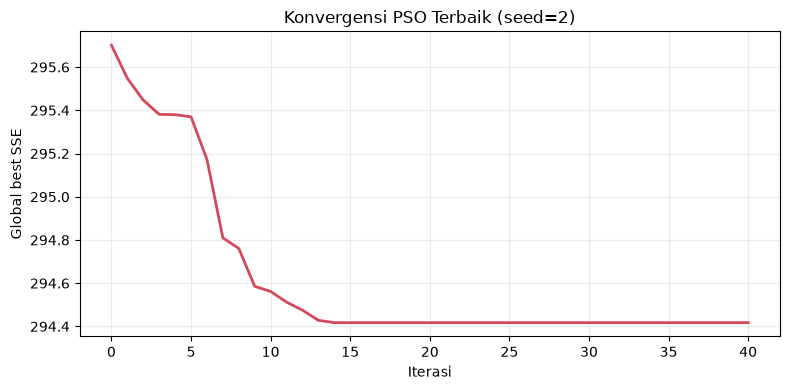

In [8]:
# BLOK 8 — Membandingkan baseline dan PSO–K-Means pada seed yang sama, lalu memilih model terbaik.
hasil_eksperimen = []
baseline_models, pso_models, histories = {}, {}, {}

# Kedua metode memakai seed yang sama agar perbandingan dimulai dari kondisi yang setara.
for seed in EXPERIMENT_SEEDS:
    mulai = time.perf_counter()
    baseline_run = KMeans(
        n_clusters=K_TERBAIK, init='random', n_init=1, max_iter=300, random_state=seed
    ).fit(X)
    waktu_baseline = time.perf_counter() - mulai
    metrik_baseline_run = hitung_metrik(X, baseline_run.labels_, baseline_run.inertia_, waktu_baseline)

    mulai = time.perf_counter()
    centroid_pso, _, history = pso_centroids(
        X, K_TERBAIK, baseline_run.cluster_centers_, N_PARTICLES, N_ITERATIONS,
        INERTIA_WEIGHT, COGNITIVE_WEIGHT, SOCIAL_WEIGHT, seed
    )
    # K-Means final menyempurnakan centroid hasil PSO hingga konvergen dengan prosedur Lloyd.
    pso_run = KMeans(
        n_clusters=K_TERBAIK, init=centroid_pso, n_init=1, max_iter=300, random_state=seed
    ).fit(X)
    waktu_pso = time.perf_counter() - mulai
    metrik_pso_run = hitung_metrik(X, pso_run.labels_, pso_run.inertia_, waktu_pso)

    baseline_models[seed], pso_models[seed], histories[seed] = baseline_run, pso_run, history
    hasil_eksperimen.extend([
        {'seed': seed, 'metode': 'K-Means baseline', **metrik_baseline_run},
        {'seed': seed, 'metode': 'PSO–K-Means', **metrik_pso_run},
    ])

df_eksperimen = pd.DataFrame(hasil_eksperimen)
# Seed terbaik dipilih dari SSE PSO–K-Means terendah, lalu dipakai untuk pelabelan akhir.
best_seed = int(df_eksperimen.query("metode == 'PSO–K-Means'").sort_values('inertia_sse').iloc[0]['seed'])
baseline, pso_kmeans = baseline_models[best_seed], pso_models[best_seed]
label_baseline, label_pso = baseline.labels_, pso_kmeans.labels_
riwayat_pso = histories[best_seed]

display(df_eksperimen.round(5))
print(f'Model pelabelan memakai PSO–K-Means terbaik pada seed {best_seed}.')
plt.figure(figsize=(8, 4))
plt.plot(riwayat_pso, color='#D1495B', linewidth=2)
plt.title(f'Konvergensi PSO Terbaik (seed={best_seed})')
plt.xlabel('Iterasi')
plt.ylabel('Global best SSE')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Perbandingan sebelum dan sesudah optimasi

Rata-rata 10 pengulangan:


,silhouette,davies_bouldin,calinski_harabasz,inertia_sse,waktu_detik
metode,,,,,
K-Means baseline,0.111130,3.593311,21.996697,296.582599,0.038427
PSO–K-Means,0.117294,3.439903,23.342082,294.674659,0.628571


Simpangan baku 10 pengulangan:


,silhouette,davies_bouldin,calinski_harabasz,inertia_sse,waktu_detik
metode,,,,,
K-Means baseline,0.014571,0.138280,1.360444,1.940882,0.046100
PSO–K-Means,0.006145,0.148423,0.242667,0.340263,0.163687


,indikator,nilai
0,Kenaikan Silhouette,0.006165
1,Penurunan Davies–Bouldin,0.153408
2,Kenaikan Calinski–Harabasz,1.345386
3,Penurunan SSE,1.907940


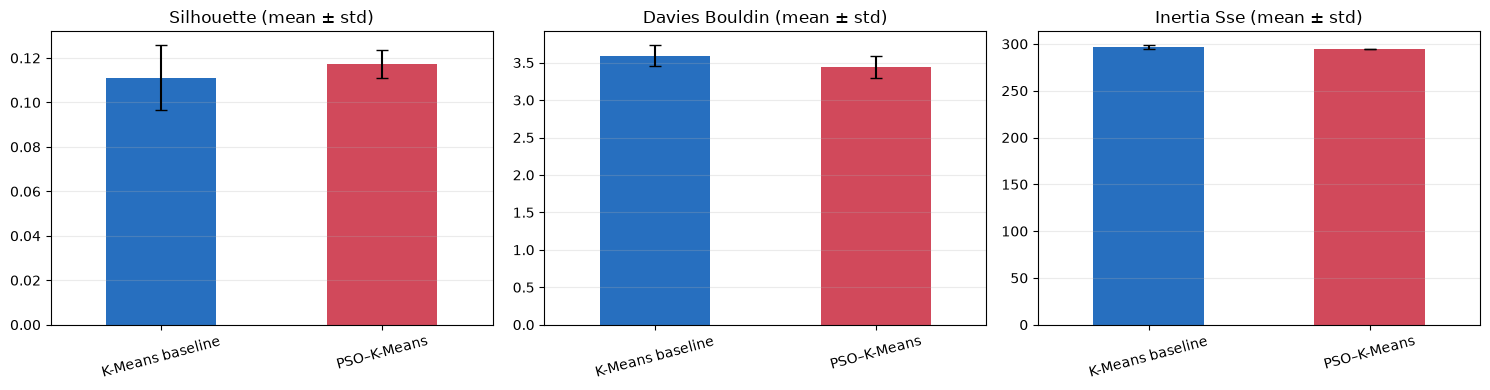

In [9]:
# BLOK 9 — Merangkum perbedaan kualitas dan kestabilan kedua metode dari seluruh pengulangan.
kolom_metrik = ['silhouette', 'davies_bouldin', 'calinski_harabasz', 'inertia_sse', 'waktu_detik']
perbandingan = df_eksperimen.groupby('metode')[kolom_metrik].mean()
perbandingan_std = df_eksperimen.groupby('metode')[kolom_metrik].std()
metrik_baseline = perbandingan.loc['K-Means baseline']
metrik_pso = perbandingan.loc['PSO–K-Means']

print('Rata-rata 10 pengulangan:')
display(perbandingan.round(6))
print('Simpangan baku 10 pengulangan:')
display(perbandingan_std.round(6))

# Arah pengurangan dibalik untuk metrik yang lebih baik bila nilainya lebih kecil.
delta = pd.DataFrame({
    'indikator': ['Kenaikan Silhouette', 'Penurunan Davies–Bouldin', 'Kenaikan Calinski–Harabasz', 'Penurunan SSE'],
    'nilai': [
        metrik_pso['silhouette'] - metrik_baseline['silhouette'],
        metrik_baseline['davies_bouldin'] - metrik_pso['davies_bouldin'],
        metrik_pso['calinski_harabasz'] - metrik_baseline['calinski_harabasz'],
        metrik_baseline['inertia_sse'] - metrik_pso['inertia_sse'],
    ]
})
display(delta.round(6))

metrics_to_plot = ['silhouette', 'davies_bouldin', 'inertia_sse']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#276FBF', '#D1495B']
for ax, metric in zip(axes, metrics_to_plot):
    perbandingan[metric].plot(kind='bar', ax=ax, color=colors,
                              yerr=perbandingan_std[metric], capsize=4)
    ax.set_title(metric.replace('_', ' ').title() + ' (mean ± std)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Pelabelan topik otomatis

In [10]:
# BLOK 10 — Mengubah nomor klaster PSO–K-Means menjadi label topik yang mudah dibaca.
# Rata-rata bobot TF-IDF per klaster menghasilkan kata kunci yang mewakili tema klaster tersebut.
def top_terms_per_cluster(X_tfidf, labels, feature_names, n_terms=8):
    rows = []
    for cluster_id in sorted(np.unique(labels)):
        mean_tfidf = np.asarray(X_tfidf[labels == cluster_id].mean(axis=0)).ravel()
        idx = mean_tfidf.argsort()[::-1][:n_terms]
        terms = feature_names[idx].tolist()
        rows.append({
            'cluster': cluster_id,
            'label_otomatis': ' / '.join(terms[:4]),
            'kata_kunci': ', '.join(terms),
        })
    return pd.DataFrame(rows)

topik = top_terms_per_cluster(X_tfidf, label_pso, feature_names, n_terms=10)
data['cluster_baseline'] = label_baseline
data['cluster_pso_kmeans'] = label_pso
data = data.merge(topik[['cluster', 'label_otomatis']], left_on='cluster_pso_kmeans', right_on='cluster', how='left')
data = data.drop(columns='cluster')

ukuran = data['cluster_pso_kmeans'].value_counts().sort_index().rename('jumlah_ulasan')
topik = topik.merge(ukuran, left_on='cluster', right_index=True, how='left')

# Pemetaan semantik otomatis berdasarkan skor kata jangkar, tidak bergantung nomor klaster.
TOPIK_SEMANTIK = {
    'Pembayaran dan layanan Samsat': ['bayar', 'bayar pajak', 'pembayaran', 'samsat', 'pungli', 'kantor'],
    'Informasi dan pengecekan pajak kendaraan': ['kendaraan', 'pajak kendaraan', 'cek pajak', 'mengetahui', 'mengecek', 'motor'],
    'Pengalaman dan kinerja aplikasi': ['membantu', 'error', 'mantap', 'bagus', 'terbuka', 'gunakan', 'cepat', 'mudah'],
}
nama_topik = list(TOPIK_SEMANTIK)
feature_index = {term: i for i, term in enumerate(feature_names)}
cluster_ids = topik['cluster'].tolist()
score_topik = np.zeros((len(cluster_ids), len(nama_topik)))
for i, cluster_id in enumerate(cluster_ids):
    mean_tfidf = np.asarray(X_tfidf[label_pso == cluster_id].mean(axis=0)).ravel()
    for j, nama in enumerate(nama_topik):
        # Skor adalah total bobot kata jangkar yang muncul pada klaster untuk setiap calon topik.
        score_topik[i, j] = sum(mean_tfidf[feature_index[k]] for k in TOPIK_SEMANTIK[nama] if k in feature_index)

# Permutasi memilih pasangan klaster-topik dengan skor total tertinggi dan mencegah topik ganda.
best_assignment = max(
    permutations(range(len(nama_topik))),
    key=lambda perm: sum(score_topik[i, perm[i]] for i in range(len(cluster_ids)))
)
LABEL_MANUAL = {cluster_ids[i]: nama_topik[best_assignment[i]] for i in range(len(cluster_ids))}
topik['label_final'] = topik.apply(
    lambda row: LABEL_MANUAL.get(row['cluster'], row['label_otomatis']), axis=1
)
data['label_topik'] = data['cluster_pso_kmeans'].map(topik.set_index('cluster')['label_final'])

display(topik)
for cluster_id in sorted(data['cluster_pso_kmeans'].unique()):
    nama = topik.loc[topik['cluster'] == cluster_id, 'label_final'].iloc[0]
    print(f'\nCLUSTER {cluster_id} — {nama}')
    display(data.loc[data['cluster_pso_kmeans'] == cluster_id, ['review_clean_final']].head(5))

,cluster,label_otomatis,kata_kunci,jumlah_ulasan,label_final
0,0,samsat / bayar / pajak / bayar pajak,"samsat, bayar, pajak, bayar pajak, pembayaran, pungli, kalau, sesuai, sama, kantor",139,Pembayaran dan layanan Samsat
1,1,kendaraan / pajak kendaraan / pajak / membantu,"kendaraan, pajak kendaraan, pajak, membantu, cek, cek pajak, membantu cek, mengetahui, mengecek, kendaraan bermotor",67,Informasi dan pengecekan pajak kendaraan
2,2,membantu / cek / error / mantap,"membantu, cek, error, mantap, bagus, pajak, kenapa, data, terbuka, wilayah",171,Pengalaman dan kinerja aplikasi



CLUSTER 0 — Pembayaran dan layanan Samsat


,review_clean_final
2,apakah tidak bisa dipermudah apabila pkb ketinggalan bisa menunjukkan pkb yg online aplikasi harusnya sih pemerintah...
5,gak bisa bayar pajakada kesalahan katanya
8,lumayan sih untuk up date
13,bahaya pegawai bagian pajak di bagian mobilbeda angka uangnya dia sebut klo cm seribu atau lbh tdk apa apain puluhan...
14,aplikasi ongol mau bayar malah disurh datang ke kantor ke kantor pengurusannya lama belum lagi punglinya hadeuh



CLUSTER 1 — Informasi dan pengecekan pajak kendaraan


,review_clean_final
1,memudahkan bagi masyarakat pengguna pajak kendaraan bermotor
3,di benahi sistem dan proses pengurusan pajak kendaraan di samsat bulukumba menunggu berjam datang baru langsung pros...
12,sangat membantu pelanggan cek pajak kendaraan karena di samsat biasa kita bayar lebih tidak sesuai dgn jumlah pajak
18,aplikasi ini membantu saya dlm cek pajak kendaraan saya
19,sangat membantu dalam mengetahui tentang pajak kendaraan



CLUSTER 2 — Pengalaman dan kinerja aplikasi


,review_clean_final
0,mantap aplikasi nya sangat membantu
4,terhitung akhir bulan mei aplikasi ini selalu error tidak bisa melakukan pengecekan padahal sudah update yang terbaru
6,mantap terimah kasih bapenda sulsel memudahkan setiap orang cek pajak kendaraanya makasi
7,katanya diskon pajak tapi di cek masih harga normal
9,ga jelas aplikasinya masa saya masukin no plat supra x keterangannya pajaknya dan besar cc mana ada supra standar pu...


## 11. Visualisasi klaster dua dimensi

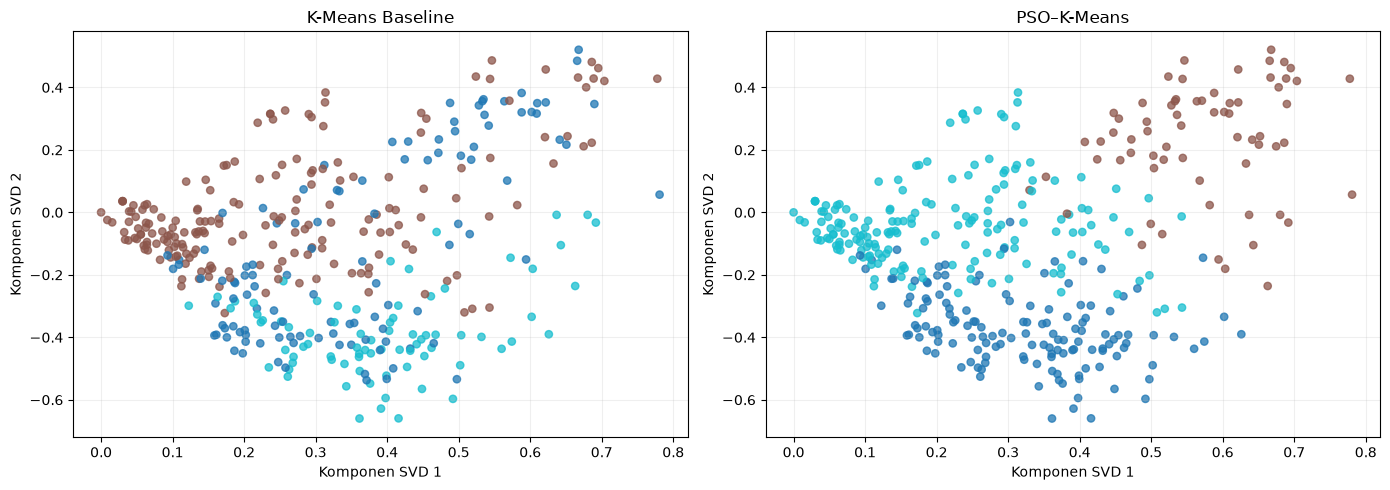

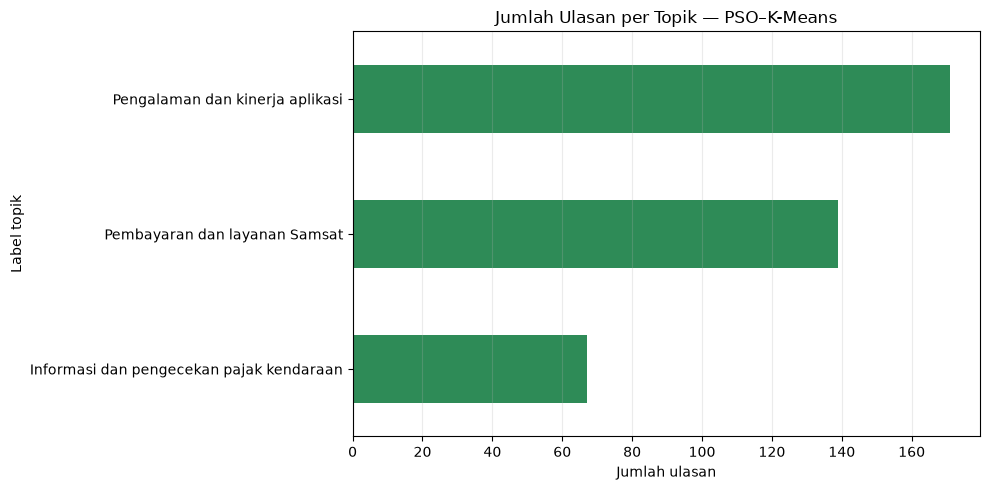

In [11]:
# BLOK 11 — Menampilkan perbandingan visual sebaran klaster dan ukuran setiap topik.
# Dua komponen LSA pertama hanya dipakai untuk visualisasi, bukan untuk proses klastering.
X_2d = X[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=label_baseline, cmap='tab10', s=28, alpha=0.75)
axes[0].set_title('K-Means Baseline')
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=label_pso, cmap='tab10', s=28, alpha=0.75)
axes[1].set_title('PSO–K-Means')
for ax in axes:
    ax.set_xlabel('Komponen SVD 1')
    ax.set_ylabel('Komponen SVD 2')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

ax = topik.set_index('label_final')['jumlah_ulasan'].sort_values().plot(
    kind='barh', figsize=(10, 5), color='#2E8B57'
)
ax.set_title('Jumlah Ulasan per Topik — PSO–K-Means')
ax.set_xlabel('Jumlah ulasan')
ax.set_ylabel('Label topik')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## 12. Ekspor hasil

In [12]:
# BLOK 12 — Mengekspor hasil pelabelan, metrik, dan riwayat optimasi ke Excel serta CSV.
# Ekspor menyimpan hasil per ulasan, ringkasan topik, dan metrik agar dapat diaudit kembali.
output_excel = Path('hasil_pelabelan_topik_pso_kmeans.xlsx')
output_csv = Path('hasil_pelabelan_topik_pso_kmeans.csv')

hasil_akhir = data[[
    'review_clean_final', 'cluster_baseline', 'cluster_pso_kmeans', 'label_otomatis', 'label_topik'
]].copy()

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    hasil_akhir.to_excel(writer, sheet_name='Hasil Pelabelan', index=False)
    topik.to_excel(writer, sheet_name='Ringkasan Topik', index=False)
    perbandingan.reset_index().to_excel(writer, sheet_name='Metrik Rata-rata', index=False)
    perbandingan_std.reset_index().to_excel(writer, sheet_name='Metrik Std', index=False)
    df_eksperimen.to_excel(writer, sheet_name='Hasil per Seed', index=False)
    df_k.to_excel(writer, sheet_name='Evaluasi K', index=False)
    pd.DataFrame({'iterasi': range(len(riwayat_pso)), 'global_best_sse': riwayat_pso}).to_excel(
        writer, sheet_name='Riwayat PSO', index=False
    )

hasil_akhir.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f'Tersimpan: {output_excel.resolve()}')
print(f'Tersimpan: {output_csv.resolve()}')

Tersimpan: /home/andiakbar/Coding/VSC/Rekayasa Komputasiona/Final/hasil_pelabelan_topik_pso_kmeans.xlsx
Tersimpan: /home/andiakbar/Coding/VSC/Rekayasa Komputasiona/Final/hasil_pelabelan_topik_pso_kmeans.csv


## 13. Kesimpulan otomatis untuk bahan laporan

In [13]:
# BLOK 13 — Menyusun kesimpulan kuantitatif perbandingan baseline dan PSO–K-Means.
# Selisih positif berarti PSO–K-Means menghasilkan klaster yang lebih rapat daripada baseline.
selisih_sse = metrik_baseline['inertia_sse'] - metrik_pso['inertia_sse']
persen_sse = 100 * selisih_sse / metrik_baseline['inertia_sse']
selisih_sil = metrik_pso['silhouette'] - metrik_baseline['silhouette']

print(
    f'Berdasarkan rata-rata {len(EXPERIMENT_SEEDS)} pengulangan pada K={K_TERBAIK}, K-Means baseline menghasilkan '
    f'SSE {metrik_baseline["inertia_sse"]:.6f} dan Silhouette {metrik_baseline["silhouette"]:.6f}. '
    f'Setelah optimasi centroid menggunakan memetic PSO–K-Means, '
    f'SSE menjadi {metrik_pso["inertia_sse"]:.6f} ({persen_sse:.3f}% lebih rendah) dan '
    f'Silhouette menjadi {metrik_pso["silhouette"]:.6f} (perubahan {selisih_sil:+.6f}). '
    f'Hasil ini harus dibahas bersama perubahan Davies–Bouldin, Calinski–Harabasz, dan waktu komputasi.'
)

Berdasarkan rata-rata 10 pengulangan pada K=3, K-Means baseline menghasilkan SSE 296.582599 dan Silhouette 0.111130. Setelah optimasi centroid menggunakan memetic PSO–K-Means, SSE menjadi 294.674659 (0.643% lebih rendah) dan Silhouette menjadi 0.117294 (perubahan +0.006165). Hasil ini harus dibahas bersama perubahan Davies–Bouldin, Calinski–Harabasz, dan waktu komputasi.
